# Fake News Classifier
### LR | NB | RF | XGB × TF-IDF | BOW | Lemmatization

**Workflow:**
1. Imports
2. Load data from training dataset
3. Train / Validation / Test split
4. Preprocessing
5. Feature Extraction (TF-IDF en BOW)
6. Modeltraining (LR, NB, RF, XGB) (Lineair Regression,Naive Bayse,Random Forrest,XGBoost)
7. Evaluation: Accuracy, F1, Cross-validation
8. Compare models
9. Predict targetlabels for testing dataset

## STEP 1 - Imports
Delete what is not needed when notebook is finished

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import pickle

import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

print('Setup ready!')

Setup ready!


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/domiendarmont/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/domiendarmont/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/domiendarmont/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/domiendarmont/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## STEP 2 - Load data and check

In [50]:
df = pd.read_csv('/Users/domiendarmont/Desktop/Ironhack/lab_week4_NLP/TEST:W4_project_NLP/training_data_fixed.csv')
df.fillna('', inplace=True)

print('Shape:', df.shape)
print('Empty values:', df.isnull().sum().to_dict())
print('Class distribution:')
print(df['label'].value_counts())
df.head()

Shape: (34152, 2)
Empty values: {'label': 0, 'text': 0}
Class distribution:
label
0    17572
1    16580
Name: count, dtype: int64


,label,text
0,0,donald trump sends out embarrassing new year‚s...
1,0,drunk bragging trump staffer started russian c...
2,0,sheriff david clarke becomes an internet joke ...
3,0,trump is so obsessed he even has obama‚s name ...
4,0,pope francis just called out donald trump duri...


## STAP 3 - Train / Validation / Test Split
**Important:** split VOOR before preprocessing

In [51]:
# Stap 1: splits in train (80%) en test (20%)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    df['text'], df['label'], test_size=0.2, random_state=42
)

# Stap 2: splits train verder in train (80%) en validatie (20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

print(f'Train:      {X_train.shape[0]} samples ({X_train.shape[0]/len(df)*100:.0f}%)')
print(f'Validatie:  {X_val.shape[0]} samples ({X_val.shape[0]/len(df)*100:.0f}%)')
print(f'Test:       {X_test.shape[0]} samples ({X_test.shape[0]/len(df)*100:.0f}%)')

Train:      21856 samples (64%)
Validatie:  5465 samples (16%)
Test:       6831 samples (20%)


## STAP 4 - Preprocessing
Data is allready lowercase, also no HTML. 
Steps we take : special chars → tokenization → stopwords → lemmatization

In [52]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
   
    # Special characters verwijderen
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    # Losse letters en dubbele spaties
    text = re.sub(r'\b[a-zA-Z]\b', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    # Tokenization
    tokens = word_tokenize(text)
    # Stopwords removal
    tokens = [w for w in tokens if w not in stop_words]
    # Lemmatization
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return ' '.join(tokens)

# Toepassen op train, validatie en test APART
X_train = X_train.apply(preprocess)
X_val   = X_val.apply(preprocess)
X_test  = X_test.apply(preprocess)

# Visuele check voor vs na preprocessing
print('VOOR:', df['text'].loc[X_train.index[1]])
print('NA:  ', X_train.values[1])

VOOR: harvey weinstein rape accuser has warrant issued for her arrest‚coincidence?
NA:   harvey weinstein rape accuser warrant issued arrest coincidence


## STEP 5 - Feature Extraction
**fit_transform op train** 
**transform on validatie en test** 

In [53]:
# TF-IDF
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

# BOW
cv = CountVectorizer(max_features=20000, ngram_range=(1, 2))
X_train_bow = cv.fit_transform(X_train)
X_val_bow   = cv.transform(X_val)
X_test_bow  = cv.transform(X_test)

print('TF-IDF shape:', X_train_tfidf.shape)
print('BOW shape:   ', X_train_bow.shape)

TF-IDF shape: (21856, 20000)
BOW shape:    (21856, 20000)


## STEP 6 - Modeltraining and evaluation
All models are trainded and evaluated on train, validation and test with Accuracy and F1 score.

In [54]:
models = {
    'LR + TF-IDF':  (LogisticRegression(max_iter=1000),                                      X_train_tfidf, X_val_tfidf, X_test_tfidf),
    'NB + TF-IDF':  (MultinomialNB(),                                                         X_train_tfidf, X_val_tfidf, X_test_tfidf),
    'LR + BOW':     (LogisticRegression(max_iter=1000),                                      X_train_bow,   X_val_bow,   X_test_bow),
    'NB + BOW':     (MultinomialNB(),                                                         X_train_bow,   X_val_bow,   X_test_bow),
    'RF + TF-IDF':  (RandomForestClassifier(n_estimators=100, random_state=42),              X_train_tfidf, X_val_tfidf, X_test_tfidf),
    'RF + BOW':     (RandomForestClassifier(n_estimators=100, random_state=42),              X_train_bow,   X_val_bow,   X_test_bow),
    'XGB + TF-IDF': (XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'), X_train_tfidf, X_val_tfidf, X_test_tfidf),
    'XGB + BOW':    (XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss'), X_train_bow,   X_val_bow,   X_test_bow),
}

results = {}
trained_models = {}

print(f"{'Model':<15} {'Tr Acc':>8} {'Val Acc':>8} {'Te Acc':>8} {'Tr F1':>8} {'Val F1':>8} {'Te F1':>8} {'Overfit':>8}")
print('-' * 80)

for x, (model, X_tr, X_v, X_te) in models.items():
    model.fit(X_tr, y_train)

    train_acc = accuracy_score(y_train, model.predict(X_tr))
    val_acc   = accuracy_score(y_val,   model.predict(X_v))
    test_acc  = accuracy_score(y_test,  model.predict(X_te))
    train_f1  = f1_score(y_train,       model.predict(X_tr))
    val_f1    = f1_score(y_val,         model.predict(X_v))
    test_f1   = f1_score(y_test,        model.predict(X_te))
    overfit   = abs(train_acc - test_acc)

    results[x] = (train_acc, val_acc, test_acc, train_f1, val_f1, test_f1)
    trained_models[x] = model

    print(f"{x:<15} {train_acc:>8.3f} {val_acc:>8.3f} {test_acc:>8.3f} {train_f1:>8.3f} {val_f1:>8.3f} {test_f1:>8.3f} {overfit:>8.3f}")

Model             Tr Acc  Val Acc   Te Acc    Tr F1   Val F1    Te F1  Overfit
--------------------------------------------------------------------------------
LR + TF-IDF        0.960    0.933    0.932    0.959    0.932    0.930    0.028
NB + TF-IDF        0.955    0.935    0.928    0.954    0.933    0.926    0.027
LR + BOW           0.985    0.937    0.937    0.985    0.935    0.935    0.048
NB + BOW           0.954    0.934    0.932    0.953    0.932    0.929    0.023
RF + TF-IDF        1.000    0.908    0.910    1.000    0.905    0.908    0.090
RF + BOW           1.000    0.907    0.910    1.000    0.903    0.906    0.090
XGB + TF-IDF       0.912    0.883    0.882    0.913    0.887    0.885    0.030
XGB + BOW          0.896    0.881    0.879    0.899    0.884    0.882    0.016


## STEP 7 - Cross Validation
Try different splits for security

In [55]:
models_cv = {
    'LR + TF-IDF': (LogisticRegression(max_iter=1000), X_train_tfidf),
    'NB + TF-IDF': (MultinomialNB(),                   X_train_tfidf),
    'LR + BOW':    (LogisticRegression(max_iter=1000), X_train_bow),
    'NB + BOW':    (MultinomialNB(),                   X_train_bow),
}

print(f"{'Model':<15} {'CV Gemiddelde':>15} {'Std':>8} {'Scores'}")
print('-' * 65)

for naam, (model, X_tr) in models_cv.items():
    scores = cross_val_score(model, X_tr, y_train, cv=5, scoring='accuracy')
    print(f"{naam:<15} {scores.mean():>15.3f} {scores.std():>8.3f}   {scores.round(3)}")

Model             CV Gemiddelde      Std Scores
-----------------------------------------------------------------
LR + TF-IDF               0.928    0.003   [0.933 0.929 0.925 0.926 0.929]
NB + TF-IDF               0.928    0.003   [0.931 0.925 0.925 0.929 0.931]
LR + BOW                  0.931    0.002   [0.933 0.931 0.929 0.932 0.93 ]
NB + BOW                  0.930    0.003   [0.933 0.929 0.925 0.932 0.932]


## STEP 8 - Visualisation

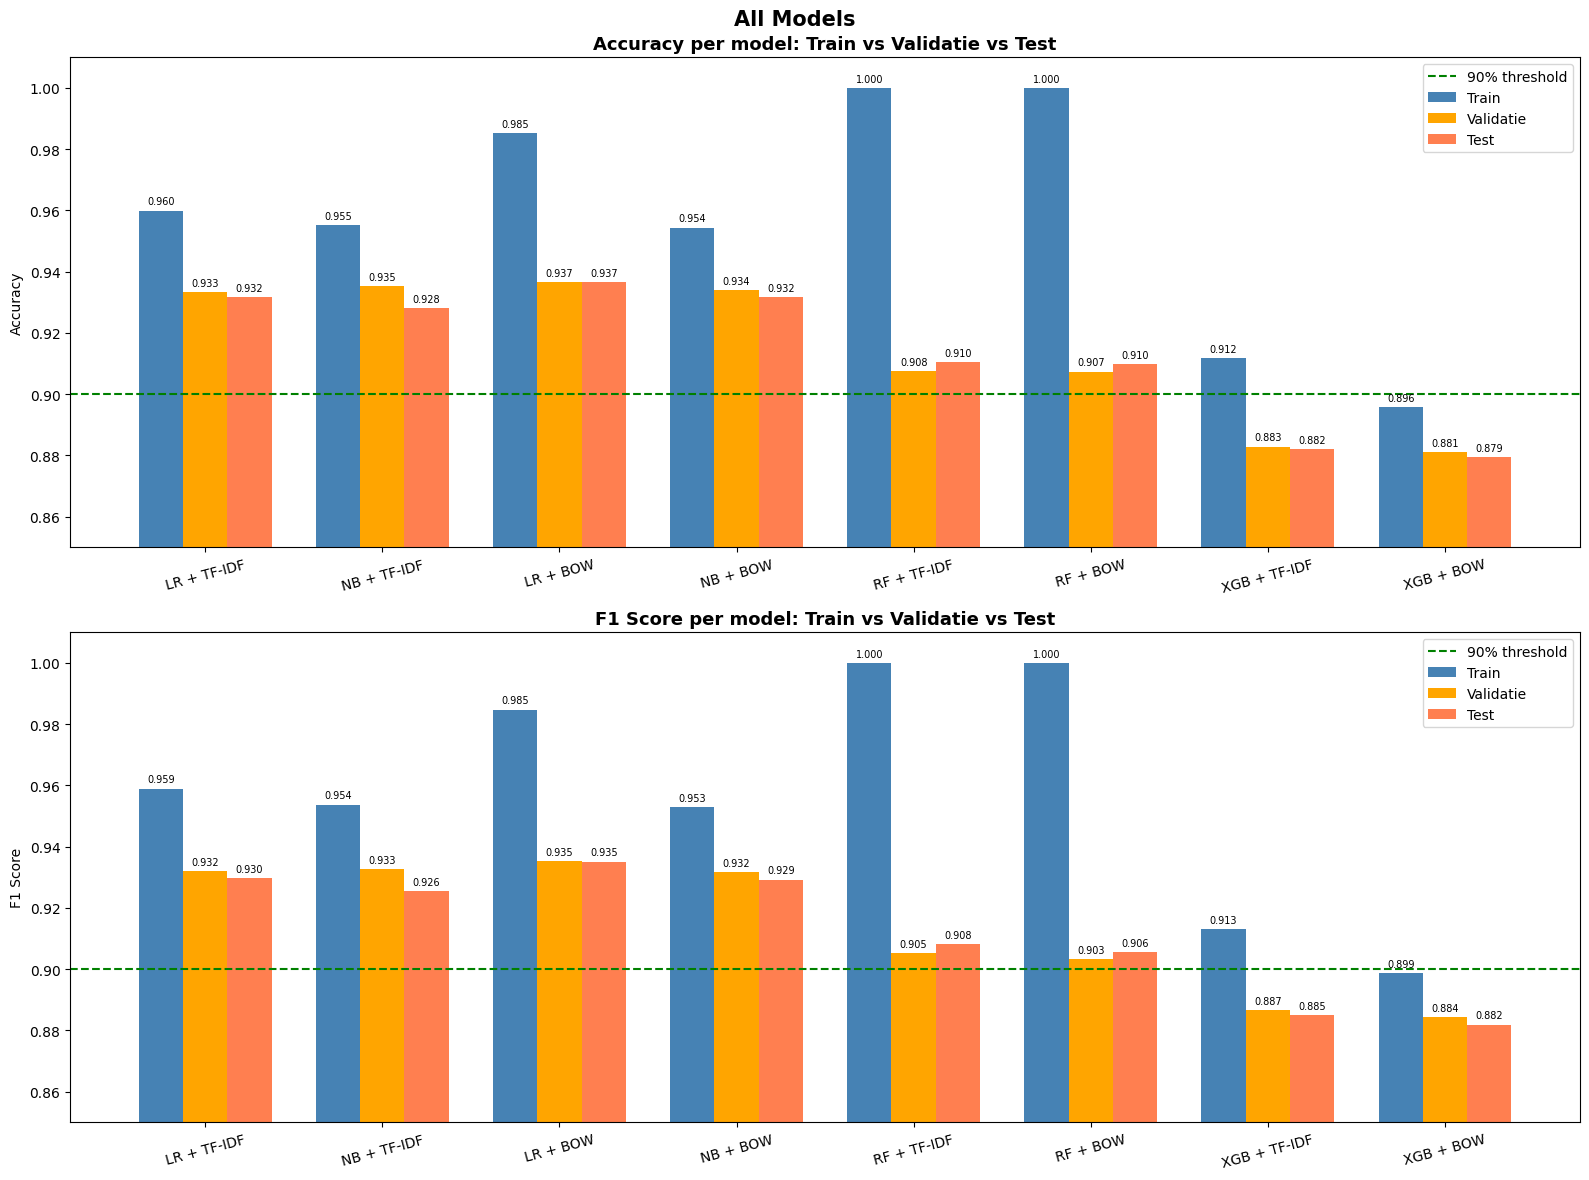

In [61]:
namen      = list(results.keys())
n_modellen = len(namen)
x          = np.arange(n_modellen)
breedte    = 0.25

train_accs = [v[0] for v in results.values()]
val_accs   = [v[1] for v in results.values()]
test_accs  = [v[2] for v in results.values()]
train_f1s  = [v[3] for v in results.values()]
val_f1s    = [v[4] for v in results.values()]
test_f1s   = [v[5] for v in results.values()]

fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# Accuracy per model - train vs val vs test
axes[0].bar(x - breedte, train_accs, breedte, label='Train',      color='steelblue')
axes[0].bar(x,           val_accs,   breedte, label='Validatie',  color='orange')
axes[0].bar(x + breedte, test_accs,  breedte, label='Test',       color='coral')
axes[0].set_title('Accuracy per model: Train vs Validatie vs Test', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(namen, rotation=15)
axes[0].set_ylim(0.85, 1.01)
axes[0].set_ylabel('Accuracy')
axes[0].axhline(y=0.9, color='green', linestyle='--', label='90% threshold')
for i, (tr, va, te) in enumerate(zip(train_accs, val_accs, test_accs)):
    axes[0].text(i - breedte, tr + 0.002, f'{tr:.3f}', ha='center', fontsize=7)
    axes[0].text(i,           va + 0.002, f'{va:.3f}', ha='center', fontsize=7)
    axes[0].text(i + breedte, te + 0.002, f'{te:.3f}', ha='center', fontsize=7)
axes[0].legend()

# F1 per model - train vs val vs test
axes[1].bar(x - breedte, train_f1s, breedte, label='Train',      color='steelblue')
axes[1].bar(x,           val_f1s,   breedte, label='Validatie',  color='orange')
axes[1].bar(x + breedte, test_f1s,  breedte, label='Test',       color='coral')
axes[1].set_title('F1 Score per model: Train vs Validatie vs Test', fontsize=13, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(namen, rotation=15)
axes[1].set_ylim(0.85, 1.01)
axes[1].set_ylabel('F1 Score')
axes[1].axhline(y=0.9, color='green', linestyle='--', label='90% threshold')
for i, (tr, va, te) in enumerate(zip(train_f1s, val_f1s, test_f1s)):
    axes[1].text(i - breedte, tr + 0.002, f'{tr:.3f}', ha='center', fontsize=7)
    axes[1].text(i,           va + 0.002, f'{va:.3f}', ha='center', fontsize=7)
    axes[1].text(i + breedte, te + 0.002, f'{te:.3f}', ha='center', fontsize=7)
axes[1].legend()

plt.suptitle('All Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

=== Classification Report: LR + BOW ===
              precision    recall  f1-score   support

    Fake (0)       0.95      0.93      0.94      3529
    Real (1)       0.93      0.94      0.94      3302

    accuracy                           0.94      6831
   macro avg       0.94      0.94      0.94      6831
weighted avg       0.94      0.94      0.94      6831



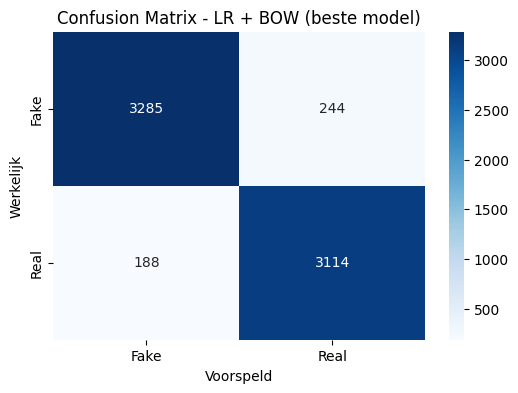

In [62]:
# Classification report en confusion matrix beste model (LR + BOW)
best_model  = trained_models['LR + BOW']
y_pred_best = best_model.predict(X_test_bow)

print('=== Classification Report: LR + BOW ===')
print(classification_report(y_test, y_pred_best, target_names=['Fake (0)', 'Real (1)']))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.title('Confusion Matrix - LR + BOW (beste model)')
plt.xlabel('Voorspeld')
plt.ylabel('Werkelijk')
plt.show()

## STAP 9 - predictions on new testdataset

In [ ]:
# load testdata
df_new = pd.read_csv('/Users/domiendarmont/Desktop/Ironhack/lab_week4_NLP/TEST:W4_project_NLP/testing_data_lowercase_nolabels.csv',
                     header=None, sep='\t', names=['id', 'text'])

# Preprocessing 
df_new['text'] = df_new['text'].apply(preprocess)

# Transform with vectorizer
X_new = cv.transform(df_new['text'])

# predict with best model that came out
df_new['label'] = best_model.predict(X_new)

print('prediction balance:')
print(f'Fake: {(df_new["label"]==0).sum()} ({(df_new["label"]==0).mean()*100:.1f}%)')
print(f'Real: {(df_new["label"]==1).sum()} ({(df_new["label"]==1).mean()*100:.1f}%)')

# Opslaan voor submission
df_new[['id', 'label']].to_csv('submission.csv', index=False)
print('\nsaved as submission.csv')
df_new.head()

prediction balance:
Fake: 4665 (46.7%)
Real: 5319 (53.3%)

saved as submission.csv


,id,text,label
0,2,copycat muslim terrorist arrested assault weapon,0
1,2,wow chicago protester caught camera admits vio...,0
2,2,germany fdp look fill schaeuble big shoe,0
3,2,mi school sends welcome back packet warning ki...,0
4,2,seek massive aid boost amid rohingya emergency...,1


## STEP 10 - Save best model

In [59]:
with open('model_lr_bow.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('vectorizer_bow.pkl', 'wb') as f:
    pickle.dump(cv, f)

print('Model en vectorizer opgeslagen!')

Model en vectorizer opgeslagen!


In [60]:
print(f"{'Model':<15} {'SW':>4} {'Punct':>6} {'Num':>4} {'Stem':>5} {'Lemma':>6} {'TFIDF':>6} {'BOW':>4} {'Ngram':>6} {'F1tr':>6} {'F1val':>6} {'F1te':>6} {'Acctr':>6} {'Accval':>6} {'Accte':>6}")
print('-' * 110)

preprocessing = {
    'Stopwords':    '✓',
    'Punctuation':  '✓',
    'Numbers':      '✓',
    'Stemming':     '✗',
    'Lemmatization':'✓',
    'N-gram':       '(1,2)'
}

for naam, (tr_acc, val_acc, te_acc, tr_f1, val_f1, te_f1) in results.items():
    tfidf_flag = '✓' if 'TF-IDF' in naam else '✗'
    bow_flag   = '✓' if 'BOW'    in naam else '✗'
    print(f"{naam:<15} {'✓':>4} {'✓':>6} {'✓':>4} {'✗':>5} {'✓':>6} {tfidf_flag:>6} {bow_flag:>4} {'(1,2)':>6} {tr_f1:>6.3f} {val_f1:>6.3f} {te_f1:>6.3f} {tr_acc:>6.3f} {val_acc:>6.3f} {te_acc:>6.3f}")

Model             SW  Punct  Num  Stem  Lemma  TFIDF  BOW  Ngram   F1tr  F1val   F1te  Acctr Accval  Accte
--------------------------------------------------------------------------------------------------------------
LR + TF-IDF        ✓      ✓    ✓     ✗      ✓      ✓    ✗  (1,2)  0.959  0.932  0.930  0.960  0.933  0.932
NB + TF-IDF        ✓      ✓    ✓     ✗      ✓      ✓    ✗  (1,2)  0.954  0.933  0.926  0.955  0.935  0.928
LR + BOW           ✓      ✓    ✓     ✗      ✓      ✗    ✓  (1,2)  0.985  0.935  0.935  0.985  0.937  0.937
NB + BOW           ✓      ✓    ✓     ✗      ✓      ✗    ✓  (1,2)  0.953  0.932  0.929  0.954  0.934  0.932
RF + TF-IDF        ✓      ✓    ✓     ✗      ✓      ✓    ✗  (1,2)  1.000  0.905  0.908  1.000  0.908  0.910
RF + BOW           ✓      ✓    ✓     ✗      ✓      ✗    ✓  (1,2)  1.000  0.903  0.906  1.000  0.907  0.910
XGB + TF-IDF       ✓      ✓    ✓     ✗      ✓      ✓    ✗  (1,2)  0.913  0.887  0.885  0.912  0.883  0.882
XGB + BOW          ✓      ✓    ✓ 